# **Preprocessing + EDA — AI-Powered Apple Leaf Specialist**

* **Name**: Aktham Almomani
* **Group**: 7

## **Introduction**

In this notebook we'll perfoming the following:

* Load config + manifests from Drive
* Summarize splits and class balance
* Check for leakage/duplicates across splits
* Inspect image sizes and show sample grids
* Compute per-channel mean/std for normalization
* Preview train augmentations (visual sanity check)
* Save plots and a small EDA report under reports/
* Update config.yaml with normalization stats

## **Setup and imports**

In [ ]:
# imports:
import os, io, json, yaml, hashlib, random
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as T

## **Load config and manifests**

Here we'll read the same config used in wrangling. Pull train/val/test manifests into DataFrames so all EDA is reproducible.

In [ ]:
# Mount Google Drive so Colab can read/write:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# point to the Drive project root:
PROJECT_ROOT = Path("/content/drive/My Drive/Colab Notebooks/apple_leaf_specialist")

# load config:
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    CFG = yaml.safe_load(f)

paths = CFG["paths"]
IMG_SIZE = CFG.get("img_size", 256)
REPORTS = Path(paths["reports"]); REPORTS.mkdir(parents=True, exist_ok=True)

# read manifests:
train_df = pd.read_csv(Path(paths["manifests"]) / "train.csv")
val_df   = pd.read_csv(Path(paths["manifests"]) / "val.csv")
test_df  = pd.read_csv(Path(paths["manifests"]) / "test.csv")

print("Rows:", len(train_df), len(val_df), len(test_df))
display(train_df.head())


Rows: 3474 475 475


,path,label
0,/content/drive/My Drive/Colab Notebooks/apple_...,black_rot
1,/content/drive/My Drive/Colab Notebooks/apple_...,black_rot
2,/content/drive/My Drive/Colab Notebooks/apple_...,black_rot
3,/content/drive/My Drive/Colab Notebooks/apple_...,healthy
4,/content/drive/My Drive/Colab Notebooks/apple_...,healthy


## **Basic split summaries**

Quick counts per split help catch obvious imbalance or empty folders.

In [ ]:
def show_counts(name, df):
    c = df["label"].value_counts().rename_axis("label").to_frame("count")
    print(name, "counts")
    display(c)

show_counts("Train", train_df)
show_counts("Val",   val_df)
show_counts("Test",  test_df)

# save counts to reports:
pd.concat({
    "train": train_df["label"].value_counts(),
    "val":   val_df["label"].value_counts(),
    "test":  test_df["label"].value_counts()
}, axis=1).fillna(0).astype(int).to_csv(REPORTS / "class_counts_by_split.csv")

Train counts


,count
label,
healthy,1146
scab,882
black_rot,870
rust,576


Val counts


,count
label,
healthy,246
scab,94
black_rot,93
rust,42


Test counts


,count
label,
healthy,246
scab,95
black_rot,93
rust,41


## **Leakage check (same file showing up in multiple splits)**

Even with care, duplicates can slip in. Since filenames are SHA-based, collisions are easy to spot.

In [ ]:
def sha_from_path(p):
    # assumes filename is <sha>.jpg or <sha>__aug_... .jpg; grab the leading hex:
    stem = Path(p).stem
    return stem.split("__aug_")[0]

train_shas = set(train_df["path"].map(sha_from_path))
val_shas   = set(val_df["path"].map(sha_from_path))
test_shas  = set(test_df["path"].map(sha_from_path))

leak_tv  = train_shas & val_shas
leak_tt  = train_shas & test_shas
leak_vt  = val_shas   & test_shas

print("Leakage train-val:", len(leak_tv))
print("Leakage train-test:", len(leak_tt))
print("Leakage val-test:", len(leak_vt))
assert len(leak_tv) == 0 and len(leak_tt) == 0 and len(leak_vt) == 0, "Found duplicates across splits!"


Leakage train-val: 0
Leakage train-test: 0
Leakage val-test: 0


## **Image size distribution**

Confirm all images are standardized to the configured size.

Reading sizes: 100%|██████████| 800/800 [12:06<00:00,  1.10it/s]


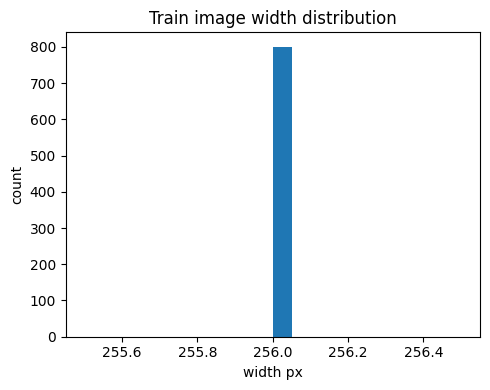

Size sample: [((np.int64(256), np.int64(256)), 800)]


In [ ]:
def sizes_of(df, n=500):
    # sample if huge:
    sample = df.sample(min(n, len(df)), random_state=CFG["seed"])
    wh = []
    for p in tqdm(sample["path"], desc="Reading sizes"):
        im = Image.open(p).convert("RGB")
        wh.append(im.size)
    return np.array(wh)

wh_train = sizes_of(train_df, n=800)
plt.figure(figsize=(5,4))
plt.hist(wh_train[:,0], bins=20)
plt.title("Train image width distribution")
plt.xlabel("width px"); plt.ylabel("count")
plt.tight_layout(); plt.savefig(REPORTS / "width_hist_train.png"); plt.show()

print("Size sample:", Counter(map(tuple, wh_train)).most_common(3))


## **Sample grids per class**

A visual pass to catch mislabels or weird artifacts.

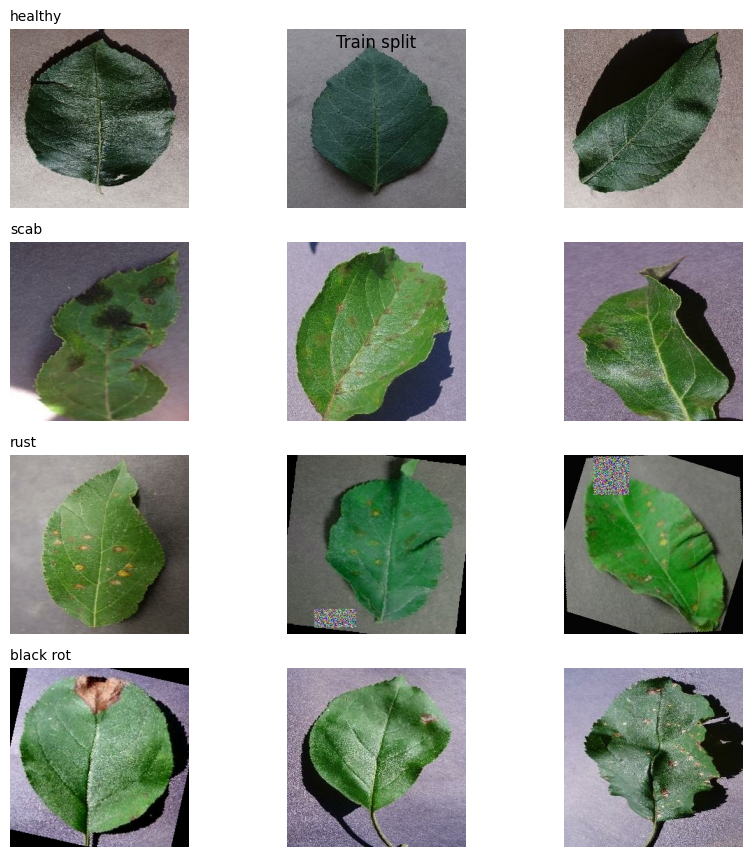

Saved: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/reports/grid_Train_split.png


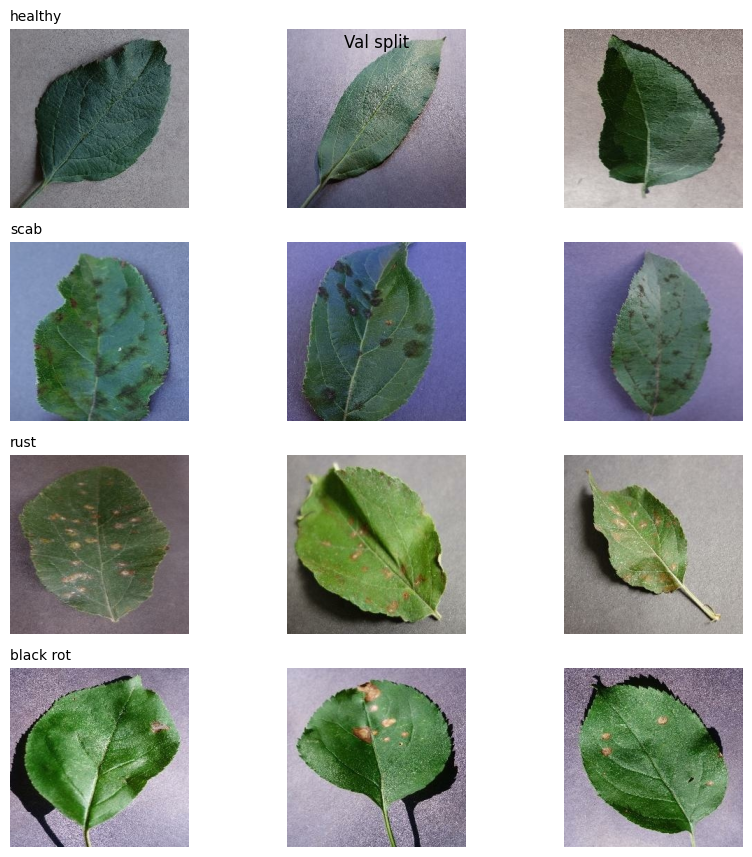

Saved: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/reports/grid_Val_split.png


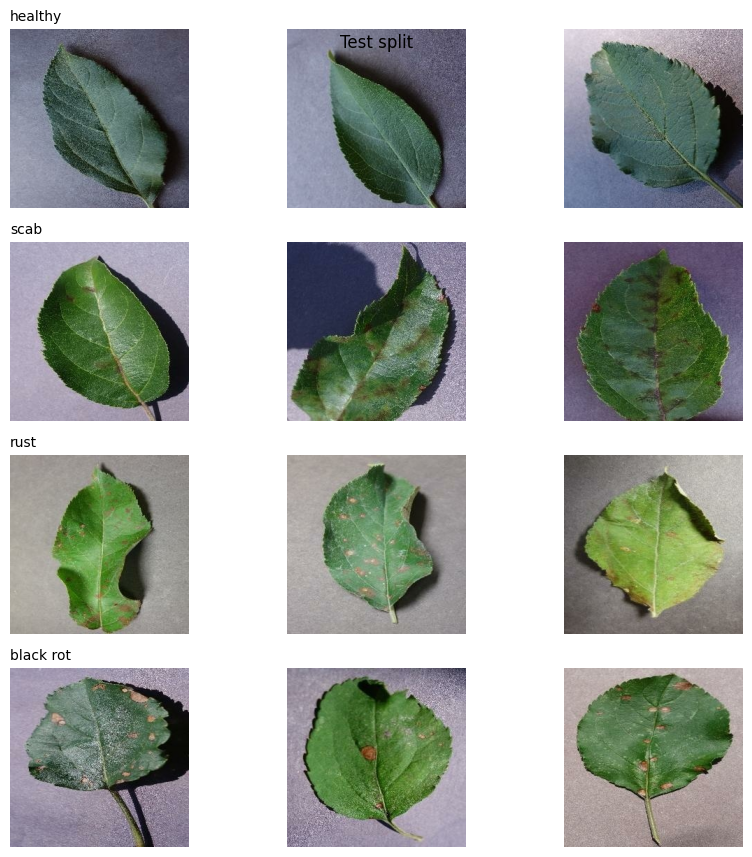

Saved: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/reports/grid_Test_split.png


In [ ]:
def show_grid(df_split, title, n_per_class=3):
    classes = ["healthy","scab","rust","black_rot"]
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(9,9))
    fig.suptitle(title, y=0.92)
    for r, cls in enumerate(classes):
        sample = df_split[df_split["label"]==cls].sample(
            min(n_per_class, (df_split["label"]==cls).sum()),
            random_state=CFG["seed"]
        )
        for c, p in enumerate(sample["path"].tolist()):
            ax = axes[r, c]
            ax.imshow(Image.open(p).convert("RGB"))
            ax.axis("off")
            if c == 0:
                ax.set_title(cls.replace("_"," "), fontsize=10, loc="left")
    plt.tight_layout()
    out = REPORTS / f"grid_{title.replace(' ','_')}.png"
    plt.savefig(out, dpi=150); plt.show()
    print("Saved:", out)

show_grid(train_df, "Train split")
show_grid(val_df,   "Val split")
show_grid(test_df,  "Test split")


## **Compute per-channel mean/std (normalization)**

Normalization speeds up training and improves stability. Compute on a decent sample of train only.

In [ ]:
def mean_std_rgb(paths, max_images=2000, resize=IMG_SIZE):
    # iterate efficiently and accumulate:
    n_used = 0
    mean = np.zeros(3, dtype=np.float64)
    sqmean = np.zeros(3, dtype=np.float64)

    sample = paths[:max_images] if len(paths) > max_images else paths
    for p in tqdm(sample, desc="Mean/Std pass"):
        im = Image.open(p).convert("RGB")
        if im.size[0] != resize or im.size[1] != resize:
            im = im.resize((resize, resize), Image.BICUBIC)
        arr = np.asarray(im, dtype=np.float32) / 255.0
        arr = arr.reshape(-1, 3)     # pixels x channels
        mean  += arr.mean(axis=0)
        sqmean += (arr**2).mean(axis=0)
        n_used += 1

    mean  /= n_used
    sqmean/= n_used
    var = sqmean - mean**2
    std = np.sqrt(np.maximum(var, 1e-8))
    return mean, std, n_used

train_paths = train_df["path"].tolist()
mean, std, n_used = mean_std_rgb(train_paths, max_images=2000, resize=IMG_SIZE)
print(f"RGB mean: {mean.round(4)}  std: {std.round(4)}  (images used: {n_used})")

# save to config:
CFG["normalization"] = {"mean": mean.tolist(), "std": std.tolist(), "img_size": IMG_SIZE}
with open(PROJECT_ROOT / "config.yaml", "w") as f:
    yaml.safe_dump(CFG, f, sort_keys=False)

# write a tiny report:
with open(REPORTS / "normalization.json", "w") as f:
    json.dump({"mean": mean.tolist(), "std": std.tolist(), "n_used": int(n_used)}, f, indent=2)


Mean/Std pass: 100%|██████████| 2000/2000 [22:20<00:00,  1.49it/s]

RGB mean: [0.429  0.4646 0.4343]  std: [0.1984 0.1725 0.2172]  (images used: 2000)


## **Augmentation preview (training only)**

Sanity check that augmentations look realistic. This mirrors the transforms planned for training.

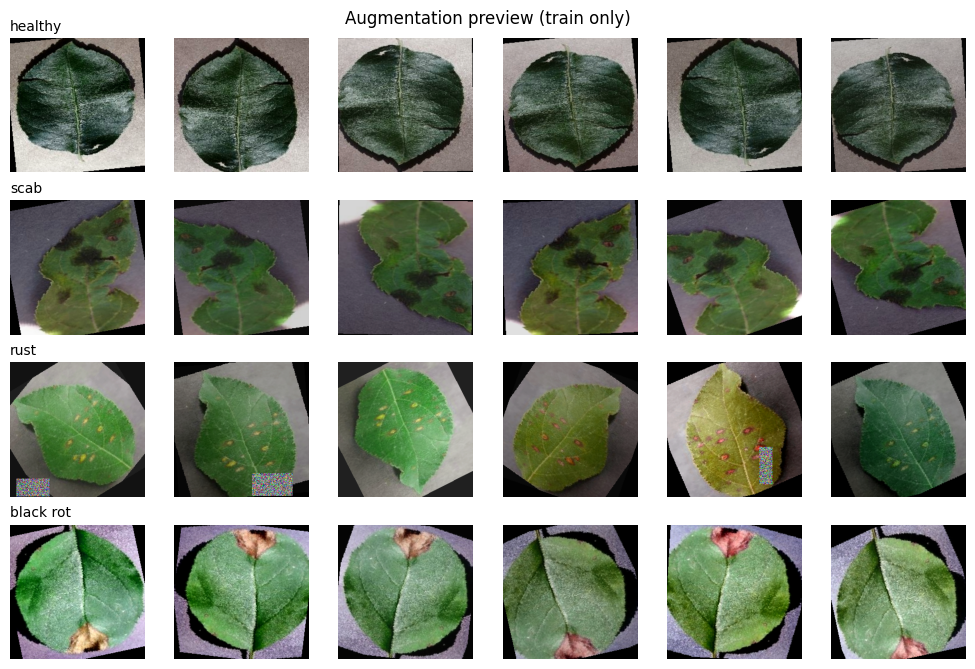

In [ ]:
# base + minority boost (same vibe as in modeling):
base_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.0), ratio=(0.9,1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=20),
    T.ColorJitter(0.15, 0.15, 0.15, 0.05),
])

extra_rotate = T.RandomRotation(degrees=35)
extra_jitter = T.ColorJitter(0.30, 0.30, 0.30, 0.10)
to_tensor   = T.ToTensor()
erasing     = T.RandomErasing(p=0.5, scale=(0.02,0.08), ratio=(0.3,3.3), value='random')
to_pil      = T.ToPILImage()

def augment_pil(pil_img, label):
    img = base_tf(pil_img)
    if label == "rust":
        img = extra_rotate(img)
        img = extra_jitter(img)
        ten = to_tensor(img)
        ten = erasing(ten)
        img = to_pil(ten)
    return img

# pick one per class and show 6 variants:
classes = ["healthy","scab","rust","black_rot"]
fig, axes = plt.subplots(len(classes), 6, figsize=(10,7))
fig.suptitle("Augmentation preview (train only)", y=0.95)
for r, cls in enumerate(classes):
    p = train_df[train_df["label"]==cls]["path"].sample(1, random_state=CFG["seed"]).iloc[0]
    src = Image.open(p).convert("RGB")
    for c in range(6):
        aug = augment_pil(src, cls)
        ax = axes[r, c]
        ax.imshow(aug); ax.axis("off")
        if c == 0:
            ax.set_title(cls.replace("_"," "), fontsize=10, loc="left")
plt.tight_layout()
plt.savefig(REPORTS / "augmentation_preview.png", dpi=150)
plt.show()


## **Save EDA summary**

In [ ]:
summary = {
    "splits": {
        "train_n": int(len(train_df)),
        "val_n":   int(len(val_df)),
        "test_n":  int(len(test_df)),
    },
    "class_counts": {
        "train": train_df["label"].value_counts().to_dict(),
        "val":   val_df["label"].value_counts().to_dict(),
        "test":  test_df["label"].value_counts().to_dict(),
    },
    "leakage": {
        "train_val": int(len(leak_tv)),
        "train_test": int(len(leak_tt)),
        "val_test": int(len(leak_vt)),
    },
    "normalization": {
        "mean": [round(x,6) for x in mean.tolist()],
        "std":  [round(x,6) for x in std.tolist()],
        "img_size": IMG_SIZE,
    }
}

with open(REPORTS / "eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("EDA artifacts written to:", REPORTS)
print("- class_counts_by_split.csv")
print("- width_hist_train.png, grid_*.png, augmentation_preview.png")
print("- normalization.json, eda_summary.json")


EDA artifacts written to: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/reports
- class_counts_by_split.csv
- width_hist_train.png, grid_*.png, augmentation_preview.png
- normalization.json, eda_summary.json
